# IV.2.2 — Spatial Characteristic Analysis of BISINDO Skeleton Data

This notebook generates visualizations to document **spatial issues/characteristics** found in the BISINDO skeleton data before pre-processing.

Three analysis groups:
1. **IV.2.2.1 — Position and Scale Variations Across Signers** → Scatter overlay, keypoint distance boxplot, multi-signer skeleton overlay
2. **IV.2.2.2 — Inter-frame Coordinate Instability (Micro-shift)** → Coordinate fluctuation line chart, displacement histogram
3. **IV.2.2.3 — [0,0] Coordinate Noise** → Noise frequency heatmap per keypoint, noise bar chart per signer, frame visualization with noise

---

In [1]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
from collections import defaultdict
import os

# ── Paper-style global rcParams (consistent with reference notebooks) ─────────
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.edgecolor'     : '#333333',
    'axes.linewidth'     : 0.8,
    'axes.grid'          : False,
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 10,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 9,
    'figure.titlesize'   : 11,
    'figure.titleweight' : 'bold',
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.05,
})

# ── Color palette ─────────────────────────────────────────────────────────────
C_LH     = '#2166AC'   # Left hand  – deep blue
C_RH     = '#D6604D'   # Right hand – muted red
C_EDGE   = '#555555'   # Skeleton edges
C_NOISE  = '#B2182B'   # Noise highlight – red
C_VALID  = '#4393C3'   # Valid keypoint
GRAYS    = ['#1a1a1a', '#555555', '#888888', '#bbbbbb']
BAR_EC   = 'black'
BAR_LW   = 0.6

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = '../data/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hand skeleton edges ───────────────────────────────────────────────────────
HAND_EDGES = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]
CONNECTIONS = [(u,v) for u,v in HAND_EDGES] + [(u+21,v+21) for u,v in HAND_EDGES]

IDX_LH   = np.arange(0, 21)    # Left hand
IDX_RH   = np.arange(21, 42)   # Right hand
IDX_HAND = np.arange(0, 42)    # Both hands

print('Configuration loaded.')

Configuration loaded.


## 0. Load Data

In [2]:
# ── CONFIGURATION — adjust path to your directory structure ─────────────
PICKLE_FILE = '../data/pickle/pose_bisindo.pkl'

with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

video_ids = list(data.keys())
print(f'Total videos : {len(video_ids)}')
print(f'Sample IDs   : {video_ids[:5]}')

# Extract signer info from video ID (format: Pxx_Sxxx_Rxx)
speakers = sorted(set(v.split('_')[0] for v in video_ids))
print(f'Signers      : {speakers}')

# Keypoint layout (86 points):
# [0:21]  = Left Hand  (21 pts)
# [21:42] = Right Hand (21 pts)
# [42:61] = Mouth      (19 pts)
# [61:86] = Pose/Body  (25 pts)
K_TOTAL = 86

Total videos : 750
Sample IDs   : ['P01_S001_R01', 'P01_S001_R02', 'P01_S001_R03', 'P01_S001_R04', 'P01_S001_R05']
Signers      : ['P01', 'P02', 'P03', 'P04', 'P05']


---
## IV.2.2.3 — [0,0] Coordinate Noise

Three visualizations:
- **Fig F** — [0,0] noise frequency heatmap per keypoint (all 86 points)
- **Fig G** — Bar chart of percentage of frames with noise per signer
- **Fig H** — Frame visualization with [0,0] keypoints (marked in red)

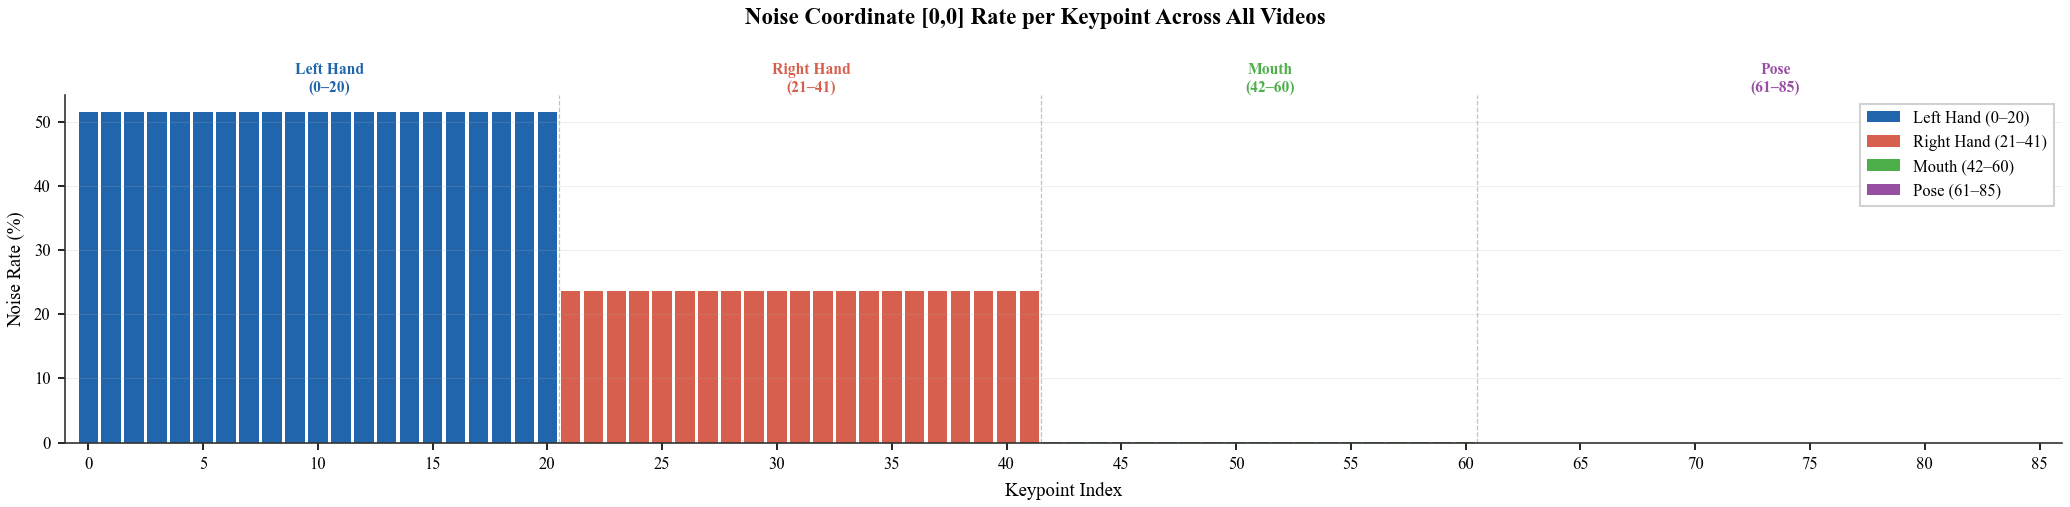

[SAVED] spatial_F_noise_heatmap.png

Top 10 keypoints with highest noise rate:
  Keypoint   0: 51.52%
  Keypoint  10: 51.52%
  Keypoint  19: 51.52%
  Keypoint  18: 51.52%
  Keypoint  17: 51.52%
  Keypoint  16: 51.52%
  Keypoint  15: 51.52%
  Keypoint  14: 51.52%
  Keypoint  13: 51.52%
  Keypoint  12: 51.52%


In [ ]:
# ── Fig F: [0,0] Noise Frequency Heatmap per Keypoint ────────────────────────
# Shows which body parts are most frequently undetected by MediaPipe

BODY_PARTS = {
    'Left Hand\n(0–20)'   : (0, 21),
    'Right Hand\n(21–41)' : (21, 42),
    'Mouth\n(42–60)'      : (42, 61),
    'Pose\n(61–85)'       : (61, 86),
}

# Calculate noise frequency per keypoint
noise_count  = np.zeros(K_TOTAL)
total_frames = np.zeros(K_TOTAL)

for vid in video_ids:
    kp = data[vid]['keypoints']  # (T, K, 2)
    T  = kp.shape[0]
    is_noise = (kp[:,:,0] == 0) & (kp[:,:,1] == 0)  # (T, K)
    noise_count  += is_noise.sum(axis=0)
    total_frames += T

noise_rate = noise_count / total_frames  # proportion of frames with noise per keypoint

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5), dpi=150)

x = np.arange(K_TOTAL)
colors_part = ['#2166AC', '#D6604D', '#4DAF4A', '#984EA3']
part_colors = np.empty(K_TOTAL, dtype=object)
for (label, (start, end)), c in zip(BODY_PARTS.items(), colors_part):
    part_colors[start:end] = c

bars = ax.bar(x, noise_rate * 100, width=0.85,
              color=part_colors, edgecolor='none')

# Partition boundaries
for (label, (start, end)), c in zip(BODY_PARTS.items(), colors_part):
    mid = (start + end) / 2
    ax.text(mid, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5,
            label, ha='center', va='bottom', fontsize=7.5,
            color=c, fontweight='bold')
    if end < K_TOTAL:
        ax.axvline(end - 0.5, color='#999999', linewidth=0.6,
                   linestyle='--', alpha=0.6)

ax.set_xlabel('Keypoint Index')
ax.set_ylabel('Noise Rate (%)')
ax.set_xlim(-1, K_TOTAL)
ax.set_xticks(np.arange(0, K_TOTAL, 5))
ax.grid(axis='y', alpha=0.25, linewidth=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

legend_handles = [Patch(facecolor=c, label=lbl.replace('\n', ' '))
                  for (lbl, _), c in zip(BODY_PARTS.items(), colors_part)]
ax.legend(handles=legend_handles, loc='upper right',
          framealpha=0.9, edgecolor='#cccccc', fancybox=False, fontsize=8)

plt.suptitle('Noise Coordinate [0,0] Rate per Keypoint Across All Videos',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spatial_F_noise_heatmap.png'))
plt.show()

print('[SAVED] spatial_F_noise_heatmap.png')
print(f'\nTop 10 keypoints with highest noise rate:')
top10 = np.argsort(noise_rate)[::-1][:10]
for idx in top10:
    print(f'  Keypoint {idx:3d}: {noise_rate[idx]*100:.2f}%')

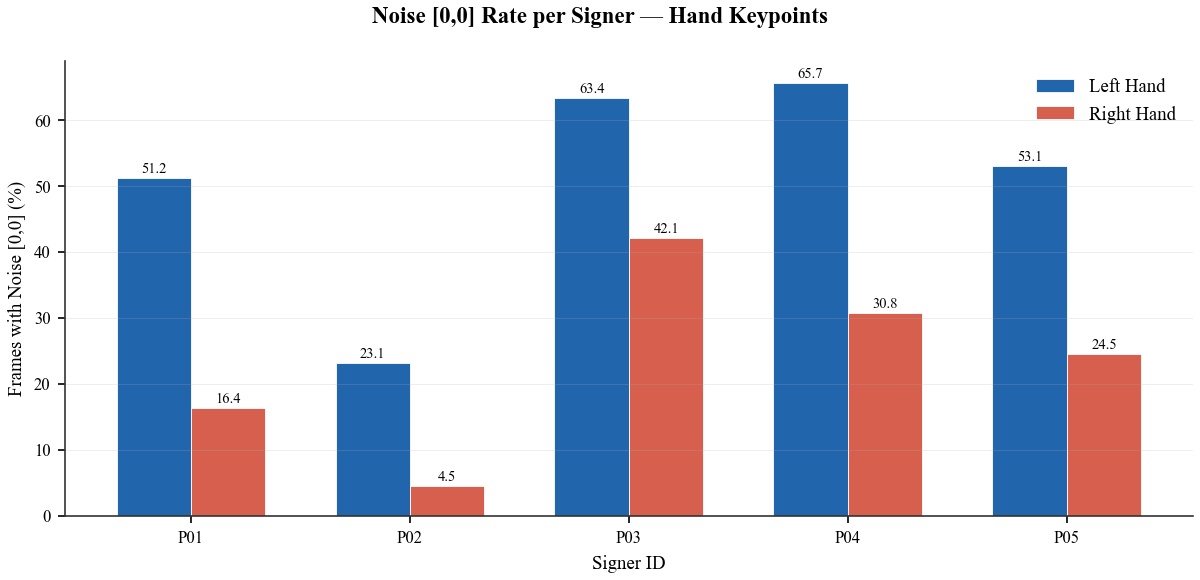

[SAVED] ../data/results\spatial_G_noise_per_signer.png


In [ ]:
# ── Fig G: Percentage of Frames with Noise per Signer ─────────────────────────
# Shows variation in MediaPipe detection quality across signers

# ── Compute Noise Rate per Hand ───────────────────────────────────────────────

sp_noise_lh, sp_noise_rh = {}, {}

for sp in speakers:

    sp_vids = [
        v for v in video_ids
        if v.startswith(sp)
    ]

    total_f = 0
    n_lh = 0
    n_rh = 0

    for vid in sp_vids:

        kp = data[vid]['keypoints']
        T  = kp.shape[0]

        # Frame considered noisy if at least one keypoint becomes [0,0]

        noise_lh = (
            (kp[:, :21, 0] == 0) &
            (kp[:, :21, 1] == 0)
        ).any(axis=1)

        noise_rh = (
            (kp[:, 21:42, 0] == 0) &
            (kp[:, 21:42, 1] == 0)
        ).any(axis=1)

        total_f += T
        n_lh += noise_lh.sum()
        n_rh += noise_rh.sum()

    sp_noise_lh[sp] = (
        n_lh / total_f * 100
        if total_f > 0 else 0
    )

    sp_noise_rh[sp] = (
        n_rh / total_f * 100
        if total_f > 0 else 0
    )

# ── Plot ──────────────────────────────────────────────────────────────────────

sp_sorted = sorted(speakers)

x = np.arange(len(sp_sorted))
w = 0.34

fig, ax = plt.subplots(
    figsize=(8.2, 4.0),
    dpi=150
)

# Left Hand
b0 = ax.bar(
    x - w/2,
    [sp_noise_lh[s] for s in sp_sorted],
    width=w,
    color='#2166AC',
    edgecolor='white',
    linewidth=0.4,
    label='Left Hand'
)

# Right Hand
b1 = ax.bar(
    x + w/2,
    [sp_noise_rh[s] for s in sp_sorted],
    width=w,
    color='#D6604D',
    edgecolor='white',
    linewidth=0.4,
    label='Right Hand'
)

# ── Value Labels ──────────────────────────────────────────────────────────────

for bars in [b0, b1]:

    for bar in bars:

        h = bar.get_height()

        if h > 0.5:

            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.4,
                f'{h:.1f}',
                ha='center',
                va='bottom',
                fontsize=7
            )

# ── Style ─────────────────────────────────────────────────────────────────────

ax.set_xticks(x)
ax.set_xticklabels(sp_sorted)

ax.set_xlabel('Signer ID')
ax.set_ylabel('Frames with Noise [0,0] (%)')

ax.legend(frameon=False)

ax.grid(
    axis='y',
    alpha=0.25,
    linewidth=0.4
)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# ── Title ─────────────────────────────────────────────────────────────────────

plt.suptitle(
    'Noise [0,0] Rate per Signer — Hand Keypoints',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_G_noise_per_signer.png'
)

plt.savefig(
    save_path,
    dpi=600
)

plt.show()

print(f'[SAVED] {save_path}')

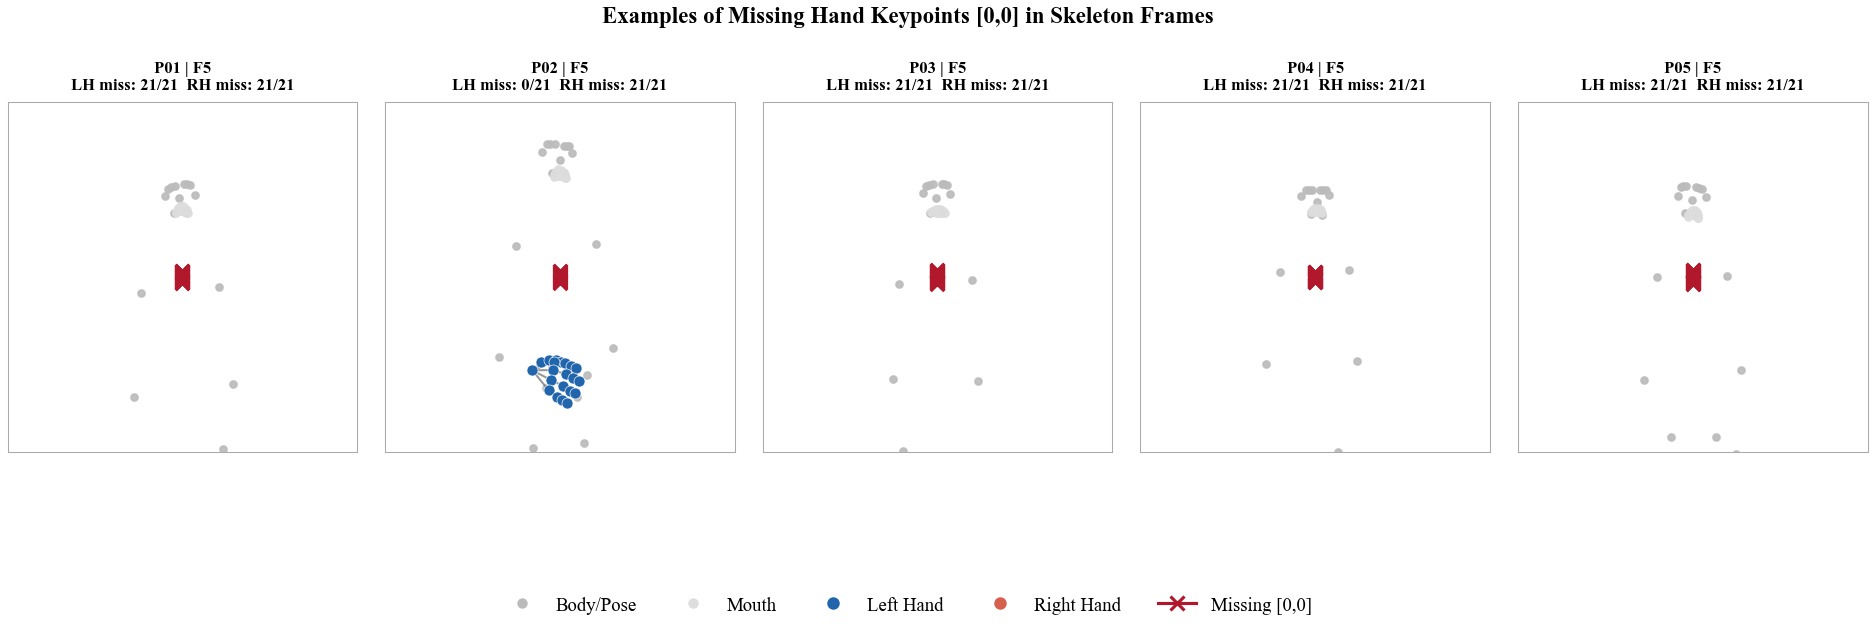

[SAVED] ../data/results\spatial_H_manual_missing_frames.png


In [ ]:
# ── Fig H: Manual Examples of Missing Keypoints [0,0] ────────────────────────
# Purpose:
# Visualize selected frames with partial missing hand keypoints
# while preserving body and mouth context.

# ── CONFIGURATION ─────────────────────────────────────────────────────────────

SELECTED_FRAMES = [

    ('P01_S023_R01', 5),
    ('P02_S023_R01', 5),
    ('P03_S023_R01', 5),
    ('P04_S023_R01', 5),
    ('P05_S023_R01', 5),
]

# Index groups
IDX_LH    = np.arange(0, 21)
IDX_RH    = np.arange(21, 42)
IDX_MOUTH = np.arange(42, 61)
IDX_POSE  = np.arange(61, 86)

# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    len(SELECTED_FRAMES),
    figsize=(3.2 * len(SELECTED_FRAMES), 4.0),
    dpi=150
)

if len(SELECTED_FRAMES) == 1:
    axes = [axes]

# ── Plot ──────────────────────────────────────────────────────────────────────

for ax, (vid, fidx) in zip(axes, SELECTED_FRAMES):

    kp = data[vid]['keypoints']

    if fidx >= kp.shape[0]:

        raise ValueError(
            f'Frame {fidx} exceeds sequence length for {vid}'
        )

    frame = kp[fidx].copy()

    is_noise = (
        (frame[:, 0] == 0) &
        (frame[:, 1] == 0)
    )

    valid = ~is_noise

    # ── Center Skeleton ──────────────────────────────────────────────────────

    valid_idx = np.where(valid)[0]

    cx = frame[valid_idx, 0].mean()
    cy = frame[valid_idx, 1].mean()

    f_plot = frame.copy().astype(float)

    f_plot[:, 0] = -(f_plot[:, 0] - cx)
    f_plot[:, 1] = -(f_plot[:, 1] - cy)

    # ── Draw Body / Pose ─────────────────────────────────────────────────────

    pose_valid = IDX_POSE[valid[IDX_POSE]]

    ax.scatter(
        f_plot[pose_valid, 0],
        f_plot[pose_valid, 1],
        s=10,
        color='#BBBBBB',
        alpha=0.9,
        zorder=1
    )

    # ── Draw Mouth ───────────────────────────────────────────────────────────

    mouth_valid = IDX_MOUTH[valid[IDX_MOUTH]]

    ax.scatter(
        f_plot[mouth_valid, 0],
        f_plot[mouth_valid, 1],
        s=10,
        color='#DDDDDD',
        alpha=0.9,
        zorder=1
    )

    # ── Draw Hand Skeleton Connections ──────────────────────────────────────

    for u, v in CONNECTIONS:

        if valid[u] and valid[v]:

            ax.plot(
                [f_plot[u, 0], f_plot[v, 0]],
                [f_plot[u, 1], f_plot[v, 1]],
                color=C_EDGE,
                linewidth=1.0,
                alpha=0.6,
                zorder=2
            )

    # ── Left Hand ────────────────────────────────────────────────────────────

    lh_valid = IDX_LH[valid[IDX_LH]]

    ax.scatter(
        f_plot[lh_valid, 0],
        f_plot[lh_valid, 1],
        s=28,
        color=C_LH,
        edgecolors='white',
        linewidths=0.3,
        zorder=3
    )

    # ── Right Hand ───────────────────────────────────────────────────────────

    rh_valid = IDX_RH[valid[IDX_RH]]

    ax.scatter(
        f_plot[rh_valid, 0],
        f_plot[rh_valid, 1],
        s=28,
        color=C_RH,
        edgecolors='white',
        linewidths=0.3,
        zorder=3
    )

    # ── Missing Hand Keypoints ───────────────────────────────────────────────

    noise_idx = np.where(is_noise[:42])[0]

    if len(noise_idx):

        ax.scatter(
            np.zeros(len(noise_idx)),
            np.linspace(-0.02, 0.02, len(noise_idx)),
            marker='x',
            s=42,
            color=C_NOISE,
            linewidths=1.4,
            zorder=4
        )

    # ── Title ────────────────────────────────────────────────────────────────

    lh_noise = is_noise[:21].sum()
    rh_noise = is_noise[21:42].sum()

    ax.set_title(
        f'{vid.split("_")[0]} | F{fidx}\n'
        f'LH miss: {lh_noise}/21  RH miss: {rh_noise}/21',
        fontsize=8
    )

    # ── Dynamic Limits ───────────────────────────────────────────────────────

    valid_points = f_plot[valid_idx]

    side = max(
        valid_points[:, 0].max() - valid_points[:, 0].min(),
        valid_points[:, 1].max() - valid_points[:, 1].min()
    ) * 1.15

    ax.set_xlim(-side/2, side/2)
    ax.set_ylim(-side/2, side/2)

    ax.set_aspect('equal')

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():

        spine.set_linewidth(0.5)
        spine.set_color('#AAAAAA')

# ── Legend ────────────────────────────────────────────────────────────────────

legend_handles = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#BBBBBB',
        markersize=6,
        label='Body/Pose'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#DDDDDD',
        markersize=6,
        label='Mouth'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=C_LH,
        markersize=7,
        label='Left Hand'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=C_RH,
        markersize=7,
        label='Right Hand'
    ),

    Line2D(
        [0], [0],
        marker='x',
        color=C_NOISE,
        markersize=7,
        markeredgewidth=1.5,
        label='Missing [0,0]'
    )
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.06),
    frameon=False
)

# ── Title ─────────────────────────────────────────────────────────────────────

plt.suptitle(
    'Examples of Missing Hand Keypoints [0,0] in Skeleton Frames',
    fontsize=11,
    fontweight='bold'
)

plt.subplots_adjust(
    wspace=0.08,
    bottom=0.18
)

# ── Save ──────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'spatial_H_manual_missing_frames.png'
)

plt.savefig(
    save_path,
    dpi=600
)

plt.show()

print(f'[SAVED] {save_path}')